# Results Analysis and Model Selection
Validate the three completed experiments, compare model size/time/accuracy, and publish the results table, figures and analysis for direct viewing.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "src").is_dir():
    raise RuntimeError("Start Jupyter in ie7615-project1 or ie7615-project1/notebooks")
sys.path.insert(0, str(ROOT))
from IPython.display import display, Markdown, Image
import pandas as pd
from src.experiment import get_active_run
from src.reporting import summarize_experiment

## Comparison and Selection
The selection rule ranks minimum validation loss first and trainable parameter count second. Test accuracy remains a held-out evaluation result.

In [2]:
RUN_DIR = get_active_run(verify_source=False)
comparison, selection = summarize_experiment(RUN_DIR)
display(comparison[["model", "total_parameters", "trainable_parameters", "training_seconds",
                    "inference_ms_median", "best_val_loss", "test_accuracy", "correct", "test_count"]])
print("Selected classifier:", selection["model"])

,model,total_parameters,trainable_parameters,training_seconds,inference_ms_median,best_val_loss,test_accuracy,correct,test_count
0,Custom_CNN,11963782,11963782,15.041685,6.416965,0.521481,0.708333,17,24
1,ResNet_Frozen,23577094,12294,24.213733,144.678457,0.352646,0.875000,21,24
2,ResNet_Finetuned,23577094,23531654,53.335375,144.180854,0.029987,0.958333,23,24


Selected classifier: ResNet_Finetuned


## Results

| Model | Total parameters | Trainable parameters | Fit time (s) | Inference (ms) | Validation loss | Test correct | Test accuracy |
|---|---:|---:|---:|---:|---:|---:|---:|
| Custom_CNN | 11,963,782 | 11,963,782 | 15.04 | 6.42 | 0.5215 | 17/24 | 70.83% |
| ResNet_Frozen | 23,577,094 | 12,294 | 24.21 | 144.68 | 0.3526 | 21/24 | 87.50% |
| ResNet_Finetuned | 23,577,094 | 23,531,654 | 53.34 | 144.18 | 0.0300 | 23/24 | 95.83% |


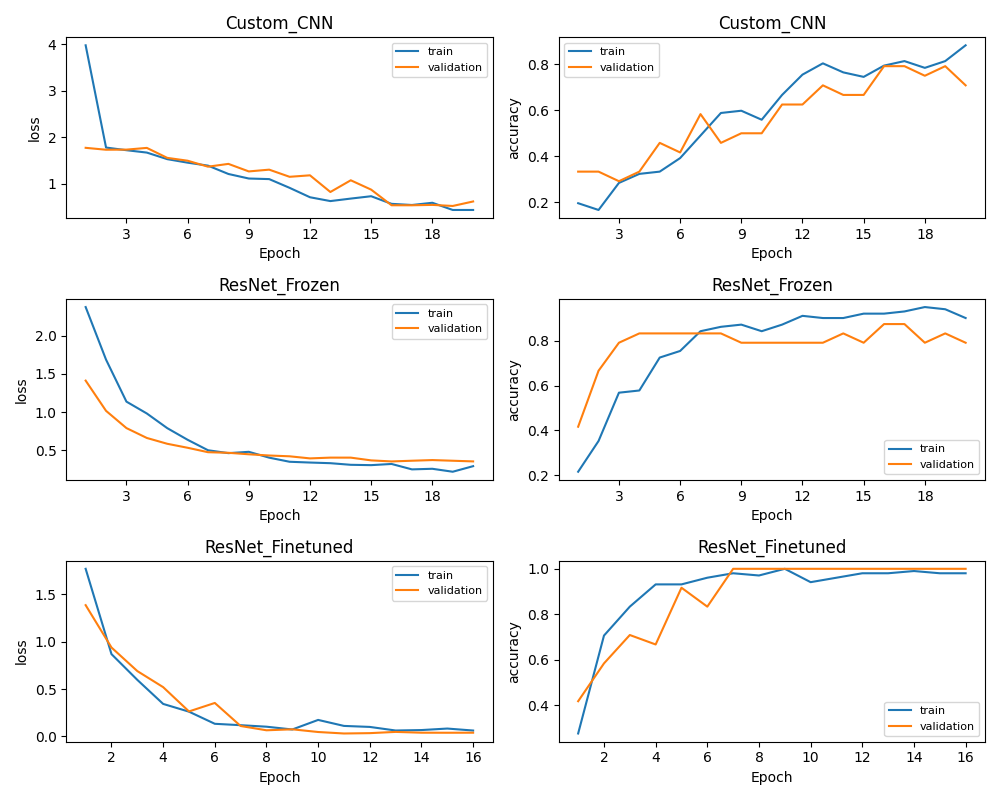

,model,identity,correct,support,accuracy
0,Custom_CNN,2336,4,4,1.00
1,Custom_CNN,2619,2,4,0.50
2,Custom_CNN,2970,2,4,0.50
3,Custom_CNN,3,4,4,1.00
4,Custom_CNN,4422,3,4,0.75
5,Custom_CNN,797,2,4,0.50
6,ResNet_Frozen,2336,4,4,1.00
7,ResNet_Frozen,2619,4,4,1.00
8,ResNet_Frozen,2970,3,4,0.75
9,ResNet_Frozen,3,4,4,1.00


,model,true_identity,predicted_identity,count
0,Custom_CNN,2619,2336,1
1,Custom_CNN,2619,3,1
2,Custom_CNN,2970,4422,2
3,Custom_CNN,4422,2970,1
4,Custom_CNN,797,2336,1
5,Custom_CNN,797,2619,1
6,ResNet_Frozen,2970,4422,1
7,ResNet_Frozen,4422,2970,1
8,ResNet_Frozen,797,3,1
9,ResNet_Finetuned,797,4422,1


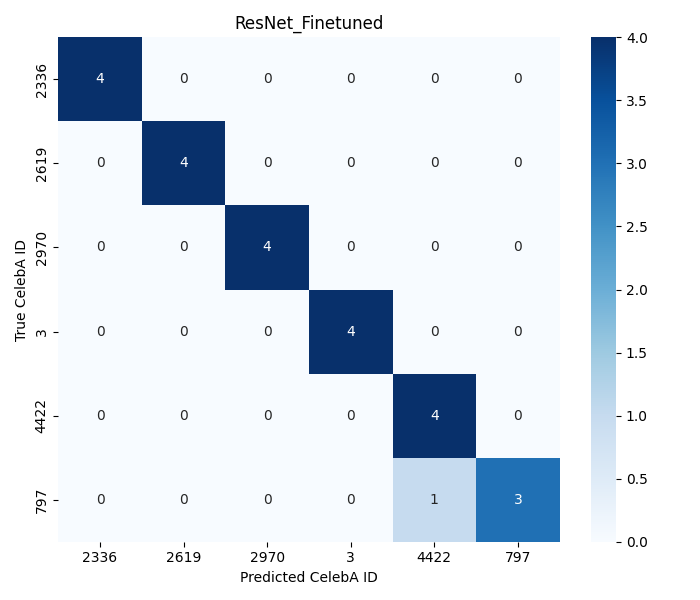

In [3]:
# Display the validated measurements and class-level results.
display(Markdown((RUN_DIR / "comparison.md").read_text(encoding="utf-8")))
display(Image(filename=str(RUN_DIR / "comparison_curves.png")))
display(pd.read_csv(RUN_DIR / "per_class_accuracy.csv"))
display(pd.read_csv(RUN_DIR / "confusion_pairs.csv"))
display(Image(filename=str(RUN_DIR / selection["model"] / "confusion_matrix.png")))